In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn

In [501]:
def create_singleBrownianData(N,sigma,T):
    delta_t = T/N
    W = np.zeros(N)
    for t in range(1,N): 
        W[t] = W[t-1]+np.sqrt(delta_t)*np.random.normal()

    X = sigma*W
    delta_X = X[1:]-X[:-1]
    

    delta_X_tens = torch.tensor(delta_X,dtype=torch.double)
    delta_X_tens = delta_X_tens
    sigma_tens = torch.tensor([sigma],dtype=torch.double)
    # print(sigma_tens.shape)



    return delta_X_tens,sigma_tens

def create_collection(N,sigma_grid,T_grid):
    m = len(sigma_grid)
   
    X_list, Y_list = [], []

    for i in range(m):
        delta_X_tens,sigma_tens = create_singleBrownianData(N,sigma_grid[i],T_grid[i])
        X_list.append(delta_X_tens),Y_list.append(sigma_tens)

    X=torch.stack(X_list); Y=torch.stack(Y_list)    
    return X,Y

In [521]:
N = 1860
n = 500
sigma_grid = np.abs(np.random.normal(size=n))+0.1
T_grid = [N]*n
X,Y = create_collection(N,sigma_grid,T_grid)

d,k = X.shape[1],Y.shape[1]
print(d,k)


1859 1


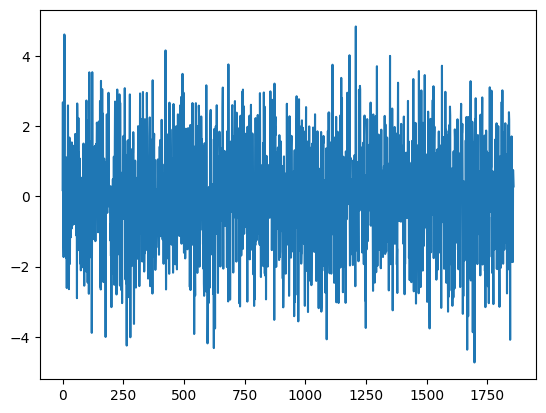

In [522]:
plt.plot(X[10])
plt.show()

In [523]:
N1,N2 = 32,4
net = nn.Sequential(nn.Linear(d,N1),nn.ReLU(),nn.Linear(N1,N2),nn.ReLU(),nn.Linear(N2,k)).to(torch.double)
print(net)

Sequential(
  (0): Linear(in_features=1859, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
)


In [524]:
epochs = 100
n = len(X)
batch_size = round(n/5) 
l = []
loss_funct = nn.MSELoss()
opt = torch.optim.SGD(net.parameters(),lr=1e-3)
for epoch in range(epochs):
    total_loss = 0
    opt.zero_grad()
    J = np.random.randint(0,n,size=batch_size)
    for i in range(batch_size):
        loss = loss_funct(net(X[J[i]]),Y[J[i]])
        loss.backward()
        total_loss += loss.item()
    opt.step()
    avg_loss = total_loss/batch_size
    l.append(avg_loss)
    if epoch%5 == 0:
        print(f"Progress: {epoch/epochs}, Loss: {avg_loss:3e}")
    

Progress: 0.0, Loss: 6.831448e-01
Progress: 0.05, Loss: 2.909915e-01
Progress: 0.1, Loss: 9.129587e-02
Progress: 0.15, Loss: 6.875009e-02
Progress: 0.2, Loss: 3.242743e-02
Progress: 0.25, Loss: 2.597175e-02
Progress: 0.3, Loss: 1.259358e-01
Progress: 0.35, Loss: 1.271186e-02
Progress: 0.4, Loss: 1.405566e-02
Progress: 0.45, Loss: 1.615780e-02
Progress: 0.5, Loss: 1.311427e-01
Progress: 0.55, Loss: 1.034285e-02
Progress: 0.6, Loss: 1.415113e-02
Progress: 0.65, Loss: 1.206225e-01
Progress: 0.7, Loss: 6.740501e-03
Progress: 0.75, Loss: 4.116129e-03
Progress: 0.8, Loss: 4.504025e-03
Progress: 0.85, Loss: 1.205376e-02
Progress: 0.9, Loss: 3.940003e-03
Progress: 0.95, Loss: 1.080813e-02


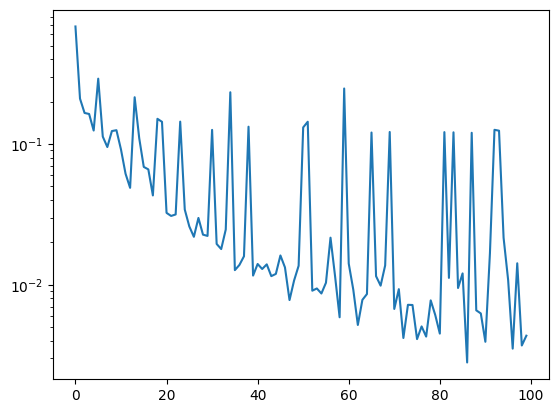

In [525]:
plt.plot(l)
plt.yscale("log")
plt.show()

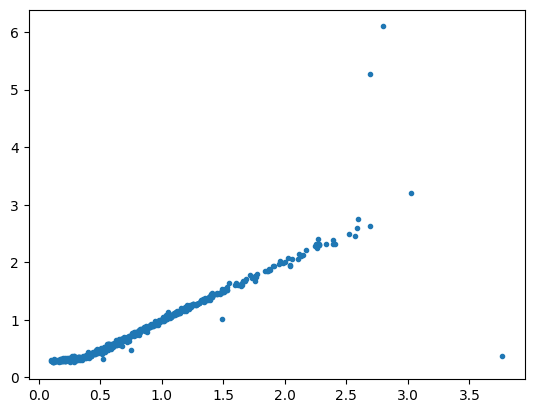

In [526]:
Y_hat = []
for i in range(n):
    Y_hat.append(net(X[i]).detach())
plt.plot(Y,Y_hat,'.')
plt.show()



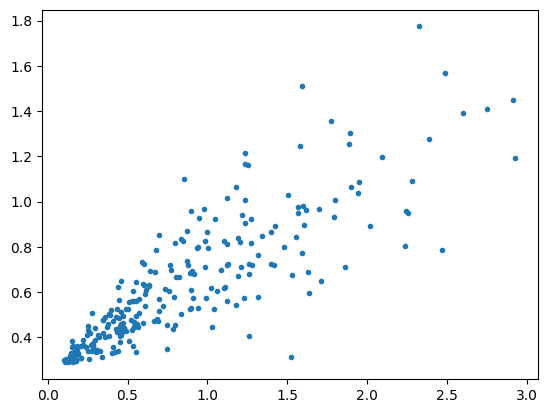

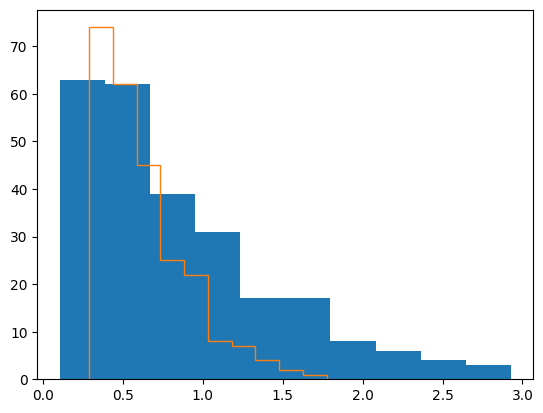

In [527]:
n_test = round(n/2)
sigmas_test = np.abs(np.random.normal(size=n_test))+0.1
X_test,Y_test = create_collection(N,sigma_grid=sigmas_test,T_grid=[N]*n_test)
Y_hat_test = []
for i in range(n_test):
    Y_hat_test.append(net(X_test[i]).detach().numpy()[0])
plt.plot(Y_test,Y_hat_test,'.')
plt.show()


plt.hist(Y_test)
plt.hist(Y_hat_test,histtype='step')
plt.show()

In [528]:
import pandas as pd


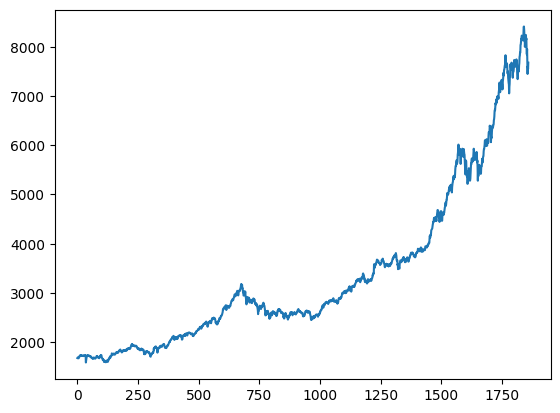

pred:0.8280457615410589,empirical:0.8556316619065348


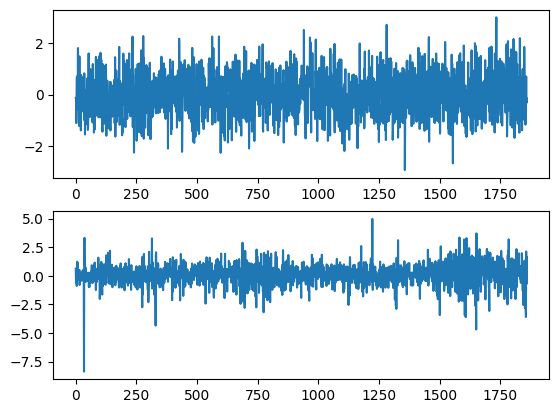

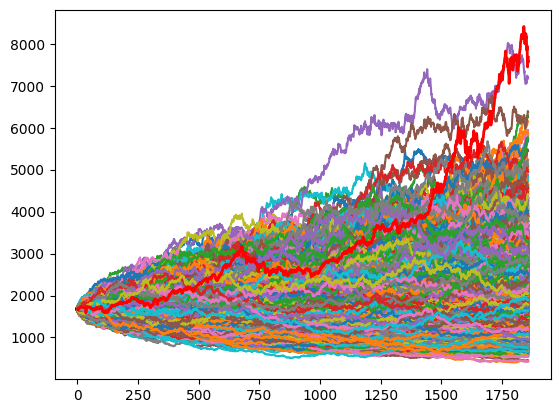

In [ ]:
dd = pd.read_csv("SMI.csv")["dd"].to_numpy()
plt.plot(dd)
plt.show()
n_paths = 10_000
X_smi = torch.tensor(np.log(dd[1:]/dd[:-1])*100)

pred_sigma = net(X_smi).detach().numpy()[0]
print(f"pred:{pred_sigma},empirical:{torch.var(X_smi)}")
smi_x, _ = create_collection(N,[pred_sigma]*n_paths,[N]*n_paths)
smi_x_np = smi_x.numpy()
X_hat = dd[0]*np.cumprod(np.exp(smi_x_np/100),axis=1)


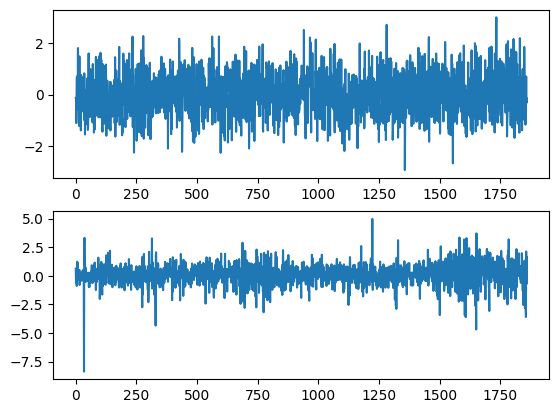

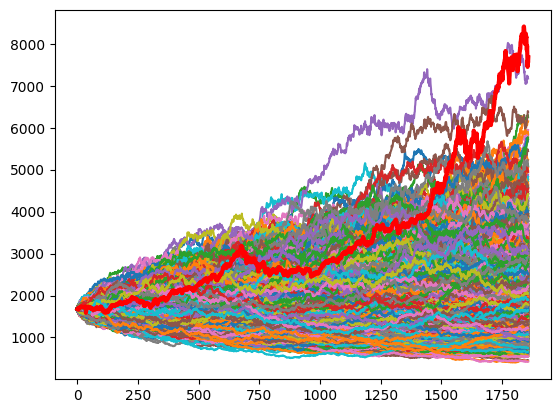

In [560]:
plt.subplot(2,1,1)
plt.plot(smi_x_np[0])
plt.subplot(2,1,2)
plt.plot(X_smi)
plt.show()

plt.plot(X_hat.T)
plt.plot(dd,'r',lw=3)
plt.show()